
# 03 推理：随机 10% 像素点作为 hint，并保存 6 张单独图片

这个 Notebook 做的事情：

1. 读取一张示例图片。
2. 在整张图中随机抽取 `10%` 像素点作为 colour hints。
3. 用训练好的 `best.pt` 预测输出的两个通道：`a_hat` 和 `b_hat`。
4. 把 input 的四张图和 output 的两张图分别保存到本地文件夹。

保存结果：

- `01_input_L.png`
- `02_input_a_hint.png`
- `03_input_b_hint.png`
- `04_input_mask.png`
- `05_output_pred_a.png`
- `06_output_pred_b.png`

说明：这里保存的 `a_hint / b_hint / pred_a / pred_b` 是**方便展示的 RGB 可视化图片**；模型内部真实使用的是 Lab 空间中归一化后的 `a,b` 数值，范围约为 `[-1, 1]`。


In [1]:

# ========== 只需要改这里 ==========
from pathlib import Path

# 你的示例图片路径：改成你给模型测试的图片
IMAGE_PATH = Path('/root/autodl-tmp/Image/example.jpg')

# 训练完成后的 checkpoint 路径
CKPT_PATH = Path('/root/autodl-tmp/Image/checkpoints/best.pt')

# 结果保存目录
OUT_DIR = Path(r"./infer_random_10pct_outputs")

# 随机抽取 10% 像素作为 hint
HINT_RATIO = 0.10
SEED = 42

# 如果图片太大导致显存/内存不够，可以设成 512 或 1024；不想缩放就用 None
MAX_SIDE = 512

# True: 在预测结果中，hint 位置强制等于原始 hint 的 a/b 值
HARD_OVERWRITE_HINTS = True
# ==================================

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("IMAGE_PATH:", IMAGE_PATH.resolve())
print("CKPT_PATH:", CKPT_PATH.resolve())
print("OUT_DIR:", OUT_DIR.resolve())


IMAGE_PATH: /root/autodl-tmp/Image/example.jpg
CKPT_PATH: /root/autodl-tmp/Image/checkpoints/best.pt
OUT_DIR: /root/autodl-tmp/Image/infer_random_10pct_outputs


In [2]:

import os
import sys
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# 让 notebook 能在两种结构下运行：
# 1) 标准项目结构：from color_points_dl.xxx import ...
# 2) 所有 .py 文件和 notebook 放在同一目录：from unet import ...
PROJECT_DIR = Path.cwd().resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

try:
    from color_points_dl.unet import UNetColorizer
    from color_points_dl.color_utils import bgr_to_lab_norm, lab_norm_to_bgr
    IMPORT_MODE = "package: color_points_dl"
except Exception as e:
    print("无法从 color_points_dl 导入，尝试从当前目录直接导入。原因：", repr(e))
    from unet import UNetColorizer
    from color_utils import bgr_to_lab_norm, lab_norm_to_bgr
    IMPORT_MODE = "local .py files"

print("Import mode:", IMPORT_MODE)
print("torch:", torch.__version__)


Import mode: package: color_points_dl
torch: 2.8.0+cu128


In [3]:

def choose_device() -> torch.device:
    """自动选择 cuda / mps / cpu。"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def torch_load_checkpoint(path: Path):
    """兼容不同 PyTorch 版本的 torch.load。"""
    try:
        return torch.load(str(path), map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(str(path), map_location="cpu")


def strip_state_dict_prefix(state_dict: dict) -> dict:
    """去掉常见的 module. 或 model. 前缀。"""
    keys = list(state_dict.keys())
    for prefix in ("module.", "model."):
        if keys and all(k.startswith(prefix) for k in keys):
            return {k[len(prefix):]: v for k, v in state_dict.items()}
    return state_dict


def infer_model_cfg_from_state_dict(state_dict: dict, payload: dict | None = None) -> dict:
    """优先使用 checkpoint 里的 model_cfg；没有时从权重形状推断。"""
    payload = payload or {}
    mcfg = dict(payload.get("model_cfg", {}) or {})

    # 默认值对应你的训练 notebook / UNet 设置
    in_channels = int(mcfg.get("in_channels", 4))
    out_channels = int(mcfg.get("out_channels", 2))
    base_channels = int(mcfg.get("base_channels", 64))

    # 如果 checkpoint 没保存 model_cfg，则从第一层和输出层权重推断
    w0 = state_dict.get("inc.net.0.weight", None)
    if w0 is not None and hasattr(w0, "shape"):
        base_channels = int(w0.shape[0])
        in_channels = int(w0.shape[1])

    wout = state_dict.get("outc.weight", None)
    if wout is not None and hasattr(wout, "shape"):
        out_channels = int(wout.shape[0])

    return {
        "in_channels": in_channels,
        "out_channels": out_channels,
        "base_channels": base_channels,
    }


def load_unet_from_best_pt(ckpt_path: Path, device: torch.device) -> torch.nn.Module:
    """加载 best.pt，并返回 eval 模式的 UNetColorizer。"""
    if not ckpt_path.exists():
        raise FileNotFoundError(f"找不到 checkpoint: {ckpt_path}")

    payload = torch_load_checkpoint(ckpt_path)
    if isinstance(payload, dict) and "state_dict" in payload:
        state_dict = payload["state_dict"]
        model_cfg = infer_model_cfg_from_state_dict(state_dict, payload)
    elif isinstance(payload, dict):
        state_dict = payload
        model_cfg = infer_model_cfg_from_state_dict(state_dict, {})
    else:
        raise ValueError("checkpoint 格式不支持：期望 dict 或包含 state_dict 的 dict。")

    state_dict = strip_state_dict_prefix(state_dict)
    model_cfg = infer_model_cfg_from_state_dict(state_dict, payload if isinstance(payload, dict) else {})

    model = UNetColorizer(
        in_channels=int(model_cfg["in_channels"]),
        out_channels=int(model_cfg["out_channels"]),
        base_channels=int(model_cfg["base_channels"]),
    )
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing or unexpected:
        print("Warning: checkpoint 与模型结构不是完全 strict match。")
        print("Missing keys:", missing)
        print("Unexpected keys:", unexpected)

    model = model.to(device).eval()
    print("Loaded model_cfg:", model_cfg)
    print("Device:", device)
    return model


def pad_to_multiple(x: torch.Tensor, multiple: int = 16):
    """UNet 下采样 4 次，所以 H/W 最好补到 16 的倍数。"""
    _, _, h, w = x.shape
    pad_h = (multiple - (h % multiple)) % multiple
    pad_w = (multiple - (w % multiple)) % multiple
    top = pad_h // 2
    bottom = pad_h - top
    left = pad_w // 2
    right = pad_w - left
    if pad_h == 0 and pad_w == 0:
        return x, (0, 0, 0, 0)
    x_pad = F.pad(x, (left, right, top, bottom), mode="reflect")
    return x_pad, (left, right, top, bottom)


def unpad(x: torch.Tensor, pad):
    left, right, top, bottom = pad
    if top or bottom:
        x = x[:, :, top:x.size(2)-bottom, :]
    if left or right:
        x = x[:, :, :, left:x.size(3)-right]
    return x


In [4]:

def resize_bgr_if_needed(img_bgr: np.ndarray, max_side: int | None) -> np.ndarray:
    """可选缩放，避免大图推理时显存/内存不够。"""
    if max_side is None:
        return img_bgr
    h, w = img_bgr.shape[:2]
    m = max(h, w)
    if m <= int(max_side):
        return img_bgr
    scale = float(max_side) / float(m)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)


def make_exact_random_hint_mask(h: int, w: int, ratio: float, seed: int = 42) -> np.ndarray:
    """精确随机抽取 round(ratio * H * W) 个像素点，返回 bool mask，shape=(H,W)。"""
    if not (0 < float(ratio) <= 1):
        raise ValueError("HINT_RATIO 必须在 (0, 1] 内。")
    total = int(h) * int(w)
    n_hint = max(1, int(round(total * float(ratio))))
    rng = np.random.default_rng(seed)
    flat_idx = rng.choice(total, size=n_hint, replace=False)
    mask = np.zeros(total, dtype=bool)
    mask[flat_idx] = True
    return mask.reshape(h, w)


def save_l_image(L: np.ndarray, out_path: Path) -> None:
    """保存 L 通道灰度图。L shape=(1,H,W), value in [0,1]."""
    arr = np.clip(L[0] * 255.0, 0, 255).astype(np.uint8)
    Image.fromarray(arr, mode="L").save(out_path)


def save_mask_image(mask_bool: np.ndarray, out_path: Path) -> None:
    """保存 mask：黑色=无 hint，白色=hint。"""
    arr = (mask_bool.astype(np.uint8) * 255)
    Image.fromarray(arr, mode="L").save(out_path)


def ab_to_display_rgb(values: np.ndarray, channel: str, mask: np.ndarray | None = None) -> np.ndarray:
    """把 a/b 单通道数值可视化成 RGB 图片。

    values: shape=(H,W), 通常在 [-1,1]
    channel='a': 负值偏绿，正值偏红
    channel='b': 负值偏蓝，正值偏黄
    mask=None 表示显示全图；mask 给定时只显示 hint 像素，其他区域为白色。
    """
    v = np.clip(values.astype(np.float32), -1.0, 1.0)
    h, w = v.shape
    rgb = np.ones((h, w, 3), dtype=np.float32) * 255.0

    if mask is None:
        valid = np.ones((h, w), dtype=bool)
    else:
        valid = mask.astype(bool)

    mag = np.abs(v)
    pos = (v >= 0) & valid
    neg = (v < 0) & valid

    if channel.lower() == "a":
        # +a: red; -a: green
        rgb[pos, 0] = 255
        rgb[pos, 1] = 255 * (1 - mag[pos])
        rgb[pos, 2] = 255 * (1 - mag[pos])

        rgb[neg, 0] = 255 * (1 - mag[neg])
        rgb[neg, 1] = 255
        rgb[neg, 2] = 255 * (1 - mag[neg])
    elif channel.lower() == "b":
        # +b: yellow; -b: blue
        rgb[pos, 0] = 255
        rgb[pos, 1] = 255
        rgb[pos, 2] = 255 * (1 - mag[pos])

        rgb[neg, 0] = 255 * (1 - mag[neg])
        rgb[neg, 1] = 255 * (1 - mag[neg])
        rgb[neg, 2] = 255
    else:
        raise ValueError("channel 必须是 'a' 或 'b'")

    return np.clip(rgb, 0, 255).astype(np.uint8)


def save_rgb(arr_rgb: np.ndarray, out_path: Path) -> None:
    Image.fromarray(arr_rgb.astype(np.uint8), mode="RGB").save(out_path)


In [5]:

# 读取图片，并转换到模型使用的 Lab 归一化格式
if not IMAGE_PATH.exists():
    raise FileNotFoundError(f"找不到示例图片，请先修改 IMAGE_PATH: {IMAGE_PATH}")

img_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise RuntimeError(f"OpenCV 读取图片失败: {IMAGE_PATH}")

img_bgr = resize_bgr_if_needed(img_bgr, MAX_SIDE)
h, w = img_bgr.shape[:2]
print(f"Image size used for inference: H={h}, W={w}")

# L: (1,H,W), [0,1]
# ab: (2,H,W), [-1,1]
L, ab = bgr_to_lab_norm(img_bgr)
print("L shape:", L.shape, "ab shape:", ab.shape)


Image size used for inference: H=512, W=384
L shape: (1, 512, 384) ab shape: (2, 512, 384)


In [6]:

# 随机 10% 像素点作为 hint
mask_bool = make_exact_random_hint_mask(h, w, HINT_RATIO, seed=SEED)
actual_ratio = mask_bool.mean()
print(f"Hint pixels: {mask_bool.sum()} / {h*w} = {actual_ratio:.4%}")

hint_ab = np.zeros_like(ab, dtype=np.float32)
hint_ab[0, mask_bool] = ab[0, mask_bool]  # a_hint
hint_ab[1, mask_bool] = ab[1, mask_bool]  # b_hint

mask = mask_bool[None, :, :].astype(np.float32)  # (1,H,W)

# 模型输入 x = [L, a_hint, b_hint, mask]，shape=(4,H,W)
x_in = np.concatenate([L, hint_ab, mask], axis=0).astype(np.float32)
print("Model input x shape:", x_in.shape)


Hint pixels: 19661 / 196608 = 10.0001%
Model input x shape: (4, 512, 384)


In [7]:

# 保存 input 的四张图
input_L_path = OUT_DIR / "01_input_L.png"
input_a_hint_path = OUT_DIR / "02_input_a_hint.png"
input_b_hint_path = OUT_DIR / "03_input_b_hint.png"
input_mask_path = OUT_DIR / "04_input_mask.png"

save_l_image(L, input_L_path)
save_rgb(ab_to_display_rgb(hint_ab[0], channel="a", mask=mask_bool), input_a_hint_path)
save_rgb(ab_to_display_rgb(hint_ab[1], channel="b", mask=mask_bool), input_b_hint_path)
save_mask_image(mask_bool, input_mask_path)

print("Saved input images:")
for p in [input_L_path, input_a_hint_path, input_b_hint_path, input_mask_path]:
    print(" -", p.resolve())


Saved input images:
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/01_input_L.png
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/02_input_a_hint.png
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/03_input_b_hint.png
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/04_input_mask.png


/tmp/ipykernel_3488/3766301257.py:31: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr, mode="L").save(out_path)
/tmp/ipykernel_3488/3766301257.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr_rgb.astype(np.uint8), mode="RGB").save(out_path)
/tmp/ipykernel_3488/3766301257.py:37: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr, mode="L").save(out_path)


In [8]:

# 加载 best.pt 并推理
# 输出 pred_ab: shape=(2,H,W)，分别是预测的 a_hat 和 b_hat
device = choose_device()
model = load_unet_from_best_pt(CKPT_PATH, device)

x = torch.from_numpy(x_in)[None, ...].to(device)  # (1,4,H,W)
x_pad, pad = pad_to_multiple(x, multiple=16)

with torch.no_grad():
    pred = model(x_pad)
    pred = unpad(pred, pad)

pred_ab = pred[0].detach().cpu().numpy().astype(np.float32)  # (2,H,W)

if HARD_OVERWRITE_HINTS:
    pred_ab[:, mask_bool] = hint_ab[:, mask_bool]

print("pred_ab shape:", pred_ab.shape)
print("pred a range:", float(pred_ab[0].min()), float(pred_ab[0].max()))
print("pred b range:", float(pred_ab[1].min()), float(pred_ab[1].max()))


Loaded model_cfg: {'in_channels': 4, 'out_channels': 2, 'base_channels': 64}
Device: cuda
pred_ab shape: (2, 512, 384)
pred a range: -0.23448029160499573 0.3937007784843445
pred b range: -0.5590550899505615 0.4566929042339325


In [9]:

# 保存 output 的两张图：predicted a, predicted b
output_a_path = OUT_DIR / "05_output_pred_a.png"
output_b_path = OUT_DIR / "06_output_pred_b.png"

save_rgb(ab_to_display_rgb(pred_ab[0], channel="a", mask=None), output_a_path)
save_rgb(ab_to_display_rgb(pred_ab[1], channel="b", mask=None), output_b_path)

print("Saved output images:")
for p in [output_a_path, output_b_path]:
    print(" -", p.resolve())


Saved output images:
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/05_output_pred_a.png
 - /root/autodl-tmp/Image/infer_random_10pct_outputs/06_output_pred_b.png


/tmp/ipykernel_3488/3766301257.py:86: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr_rgb.astype(np.uint8), mode="RGB").save(out_path)


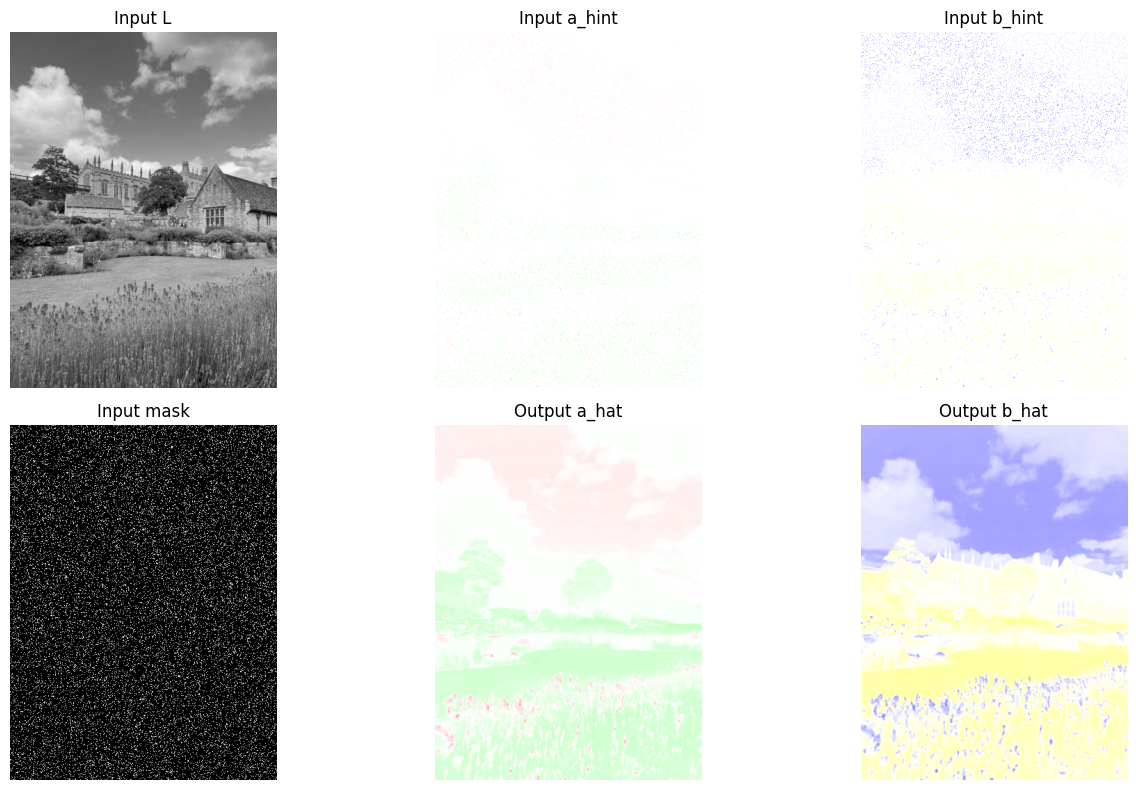

In [10]:

# 预览六张保存好的图片
saved_files = [
    ("Input L", input_L_path),
    ("Input a_hint", input_a_hint_path),
    ("Input b_hint", input_b_hint_path),
    ("Input mask", input_mask_path),
    ("Output a_hat", output_a_path),
    ("Output b_hat", output_b_path),
]

plt.figure(figsize=(14, 8))
for i, (title, path) in enumerate(saved_files, start=1):
    img = Image.open(path)
    plt.subplot(2, 3, i)
    if img.mode == "L":
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [11]:

# 最终确认：只列出这次任务要求的 6 张图片
print("本次已保存 6 张图片：")
for i, (_, path) in enumerate(saved_files, start=1):
    print(f"{i}. {path.resolve()}")


本次已保存 6 张图片：
1. /root/autodl-tmp/Image/infer_random_10pct_outputs/01_input_L.png
2. /root/autodl-tmp/Image/infer_random_10pct_outputs/02_input_a_hint.png
3. /root/autodl-tmp/Image/infer_random_10pct_outputs/03_input_b_hint.png
4. /root/autodl-tmp/Image/infer_random_10pct_outputs/04_input_mask.png
5. /root/autodl-tmp/Image/infer_random_10pct_outputs/05_output_pred_a.png
6. /root/autodl-tmp/Image/infer_random_10pct_outputs/06_output_pred_b.png
